In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/Nelo Cabab/Downloads/archive (7)/city_day.csv")

In [10]:
df_delhi = df[df['City'] == 'Delhi'].copy()
df_delhi['Date'] = pd.to_datetime(df_delhi['Date'])
df_delhi = df_delhi.sort_values('Date')

In [11]:
df_delhi.info()
df_delhi.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2009 entries, 10229 to 12237
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        2009 non-null   object        
 1   Date        2009 non-null   datetime64[ns]
 2   PM2.5       2007 non-null   float64       
 3   PM10        1932 non-null   float64       
 4   NO          2007 non-null   float64       
 5   NO2         2007 non-null   float64       
 6   NOx         2009 non-null   float64       
 7   NH3         2000 non-null   float64       
 8   CO          2009 non-null   float64       
 9   SO2         1899 non-null   float64       
 10  O3          1925 non-null   float64       
 11  Benzene     2009 non-null   float64       
 12  Toluene     2009 non-null   float64       
 13  Xylene      1228 non-null   float64       
 14  AQI         1999 non-null   float64       
 15  AQI_Bucket  1999 non-null   object        
dtypes: datetime64[ns](1), fl

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
10229,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe
10230,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe
10231,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate
10232,Delhi,2015-01-04,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,3.34,319.0,Very Poor
10233,Delhi,2015-01-05,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,2.96,325.0,Very Poor


In [12]:
print(df_delhi['Date'].min(), df_delhi['Date'].max())
print(df_delhi['Date'].diff().value_counts().head())

2015-01-01 00:00:00 2020-07-01 00:00:00
Date
1 days    2008
Name: count, dtype: int64


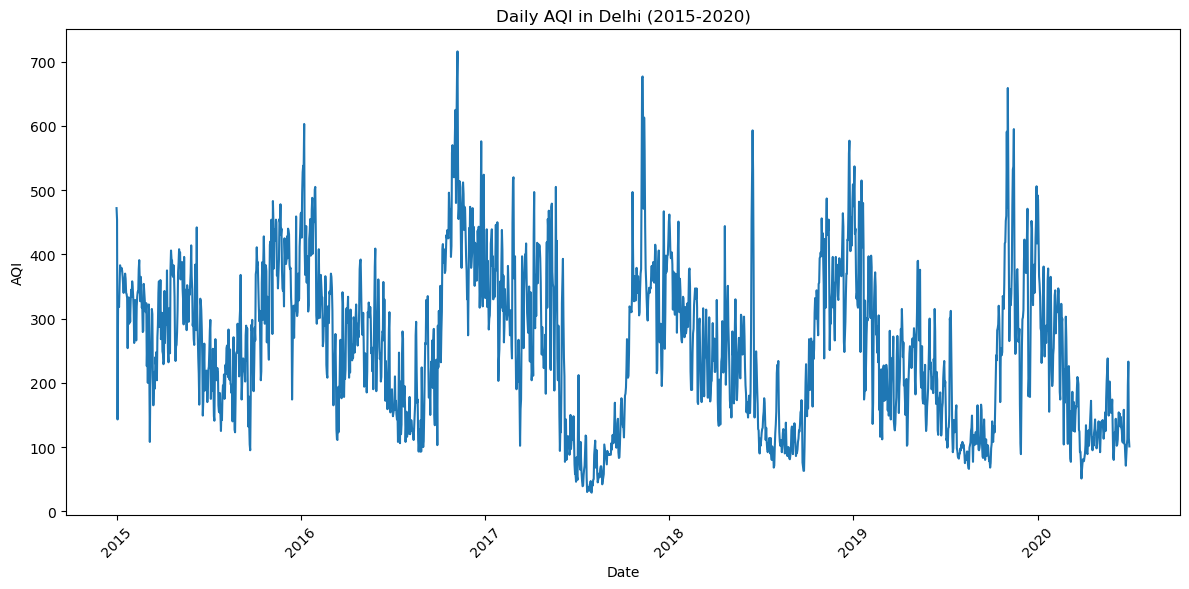

In [13]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_delhi, x="Date", y="AQI")
plt.title("Daily AQI in Delhi (2015-2020)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

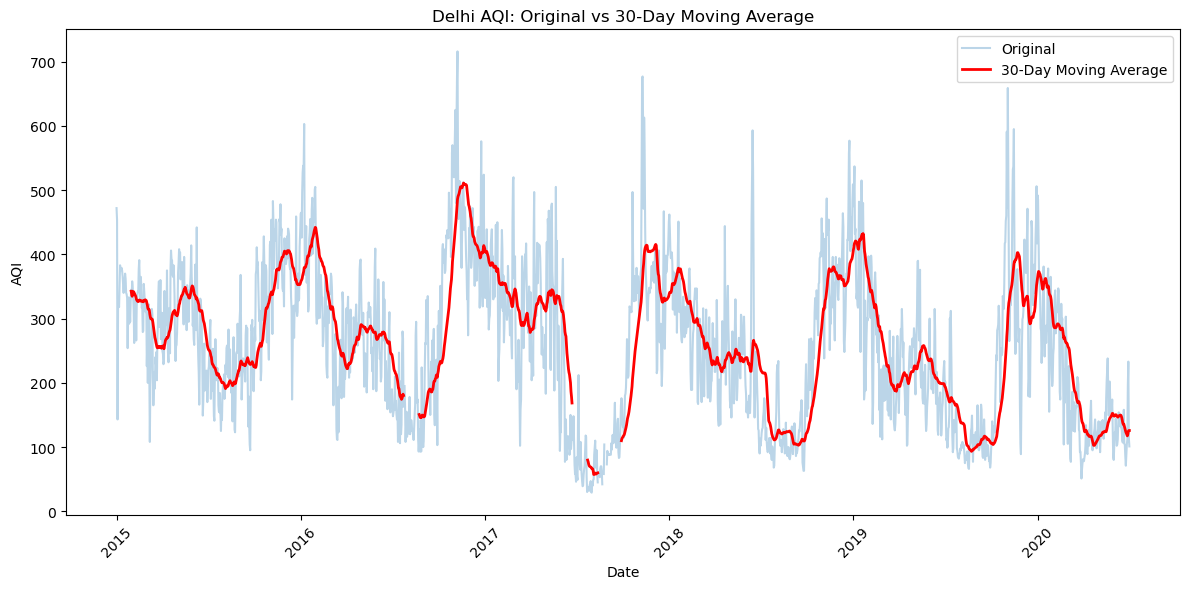

In [14]:
df_delhi["moving_average"] = df_delhi["AQI"].rolling(window=30).mean()
plt.figure(figsize=(12, 6))
plt.plot(df_delhi["Date"], df_delhi["AQI"], label="Original", alpha=0.3)
plt.plot(df_delhi["Date"], df_delhi["moving_average"], label="30-Day Moving Average", color='red', linewidth=2)
plt.title("Delhi AQI: Original vs 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

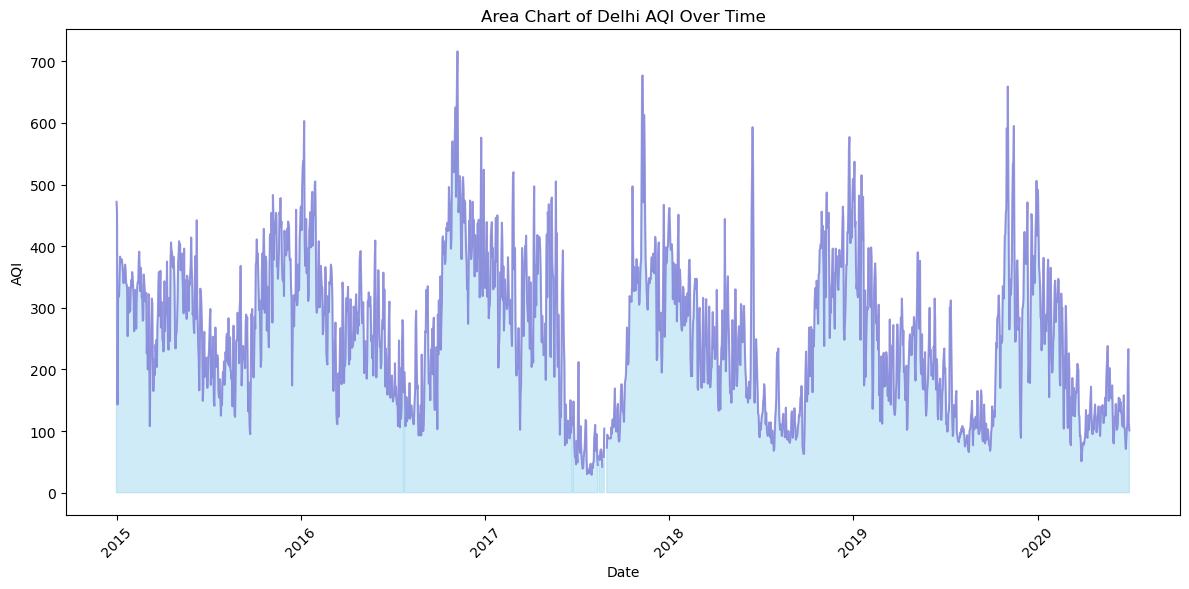

In [15]:
plt.figure(figsize=(12, 6))
plt.fill_between(df_delhi["Date"], df_delhi["AQI"], color="skyblue", alpha=0.4)
plt.plot(df_delhi["Date"], df_delhi["AQI"], color="Slateblue", alpha=0.6)
plt.title("Area Chart of Delhi AQI Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

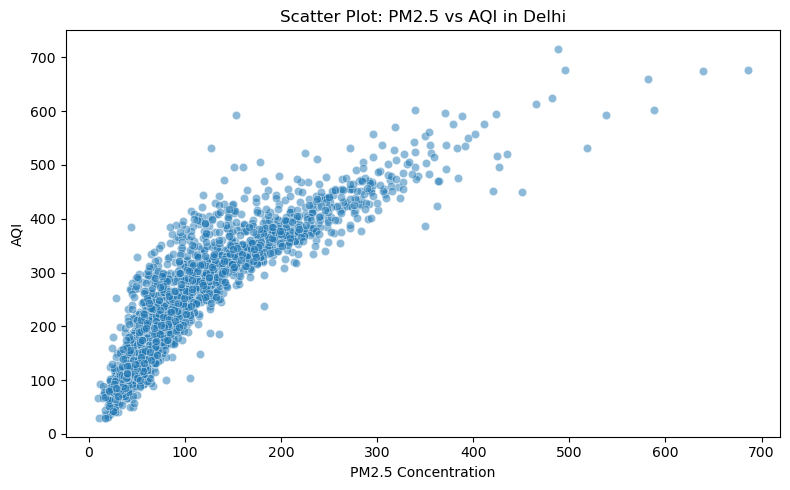

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_delhi, x="PM2.5", y="AQI", alpha=0.5)
plt.title("Scatter Plot: PM2.5 vs AQI in Delhi")
plt.xlabel("PM2.5 Concentration")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()

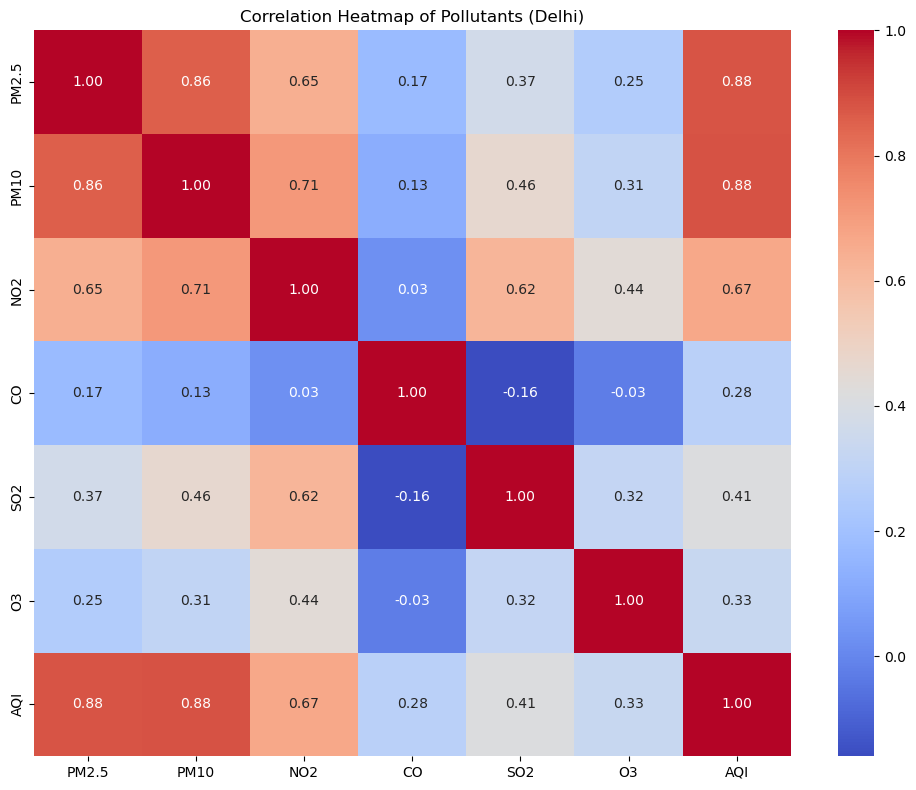

In [17]:
pollutants = ["PM2.5", "PM10", "NO2", "CO", "SO2", "O3", "AQI"]
corr_matrix = df_delhi[pollutants].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Pollutants (Delhi)")
plt.tight_layout()
plt.show()

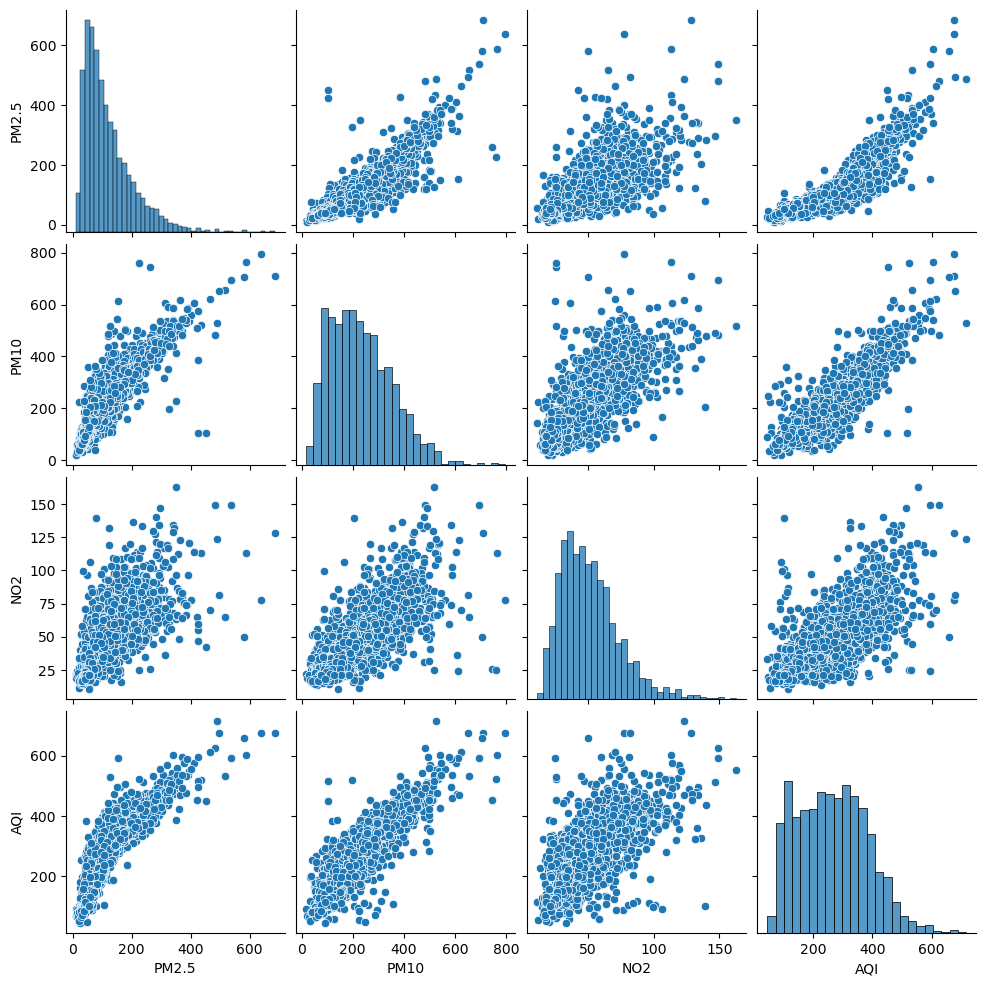

In [18]:
selected_columns = ["PM2.5", "PM10", "NO2", "AQI"]
sns.pairplot(df_delhi[selected_columns].dropna())
plt.show()

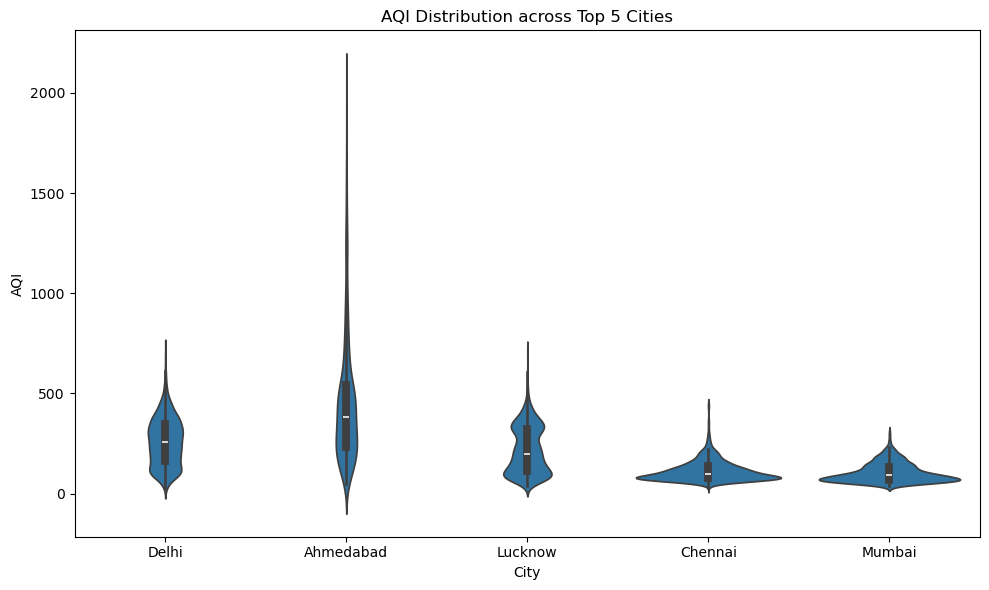

In [19]:
top_cities = df['City'].value_counts().head(5).index
df_top = df[df['City'].isin(top_cities)].dropna(subset=['AQI'])
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_top, x="City", y="AQI")
plt.title("AQI Distribution across Top 5 Cities")
plt.xlabel("City")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()